<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=302102806" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import sys
import matplotlib.pyplot as plt

# --- 1. LE REMÈDE ANTI-CRASH PYTORCH (OBLIGATOIRE EN PREMIER) ---
import torch
# On force PyTorch à charger ses modules CUDA tout de suite
_ = torch.cuda.is_available() 
print(f"✅ PyTorch {torch.__version__} est réveillé et prêt.")

# --- 2. TÉLÉCHARGEMENT DE TA LIBRAIRIE ---
# J'utilise la branche dev-leila2 comme sur tes précédentes captures. 
# Si tu as fusionné sur main, remplace 'dev-leila2' par 'main' dans l'URL.
GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/dev-leila2/notebooks/data_pipeline.py"

print("📥 Téléchargement de data_pipeline.py...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

# --- 3. IMPORTATION ---
try:
    # Nettoyage du cache au cas où tu relances la cellule
    if 'data_pipeline' in sys.modules:
        import importlib
        importlib.reload(sys.modules['data_pipeline'])
        
    from data_pipeline import get_dataloaders, show_sample_batch
    print("✅ Fichier data_pipeline.py importé avec succès sans crash !")
except Exception as e:
    print(f"❌ Erreur : {e}")

# --- 4. LE NOUVEAU DATASET ---
# Basé sur ta capture d'écran, voici le chemin exact
DATA_DIR = "/kaggle/input/private-dataset/neurosight-mri-dataset/OriginalDataset"

if os.path.exists(DATA_DIR):
    print(f"📂 Dataset trouvé à l'adresse : {DATA_DIR}")
else:
    print(f"❌ ERREUR : Dataset introuvable. As-tu bien fait '+ Add Input' dans Kaggle ?")

✅ PyTorch 2.9.0+cu126 est réveillé et prêt.
📥 Téléchargement de data_pipeline.py...
✅ Fichier data_pipeline.py importé avec succès sans crash !
📂 Dataset trouvé à l'adresse : /kaggle/input/private-dataset/neurosight-mri-dataset/OriginalDataset


🚀 Usine à données prête ! Classes détectées : ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


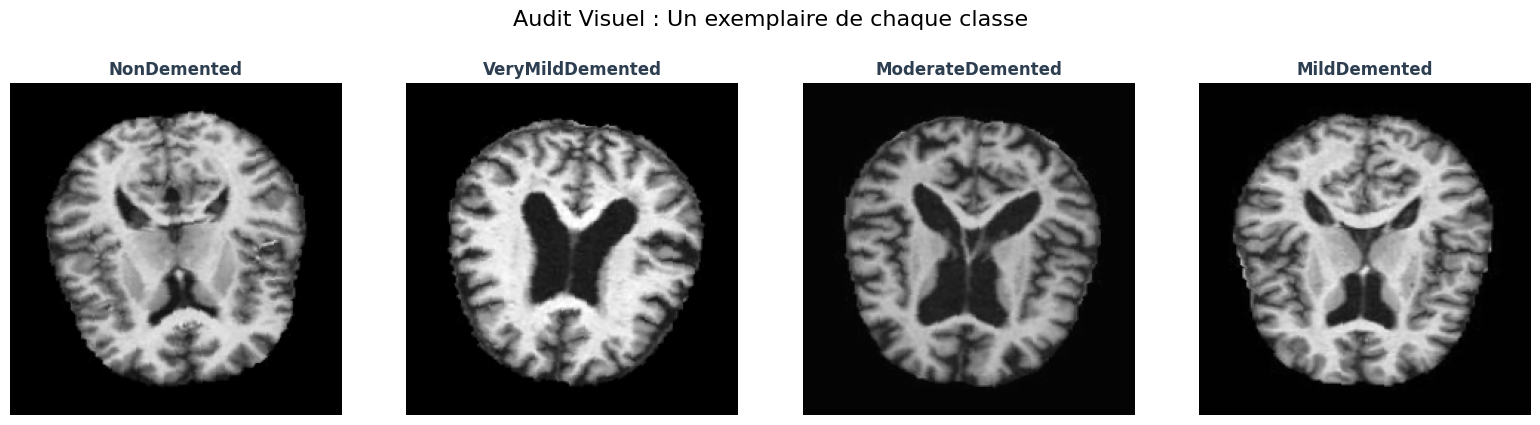

In [2]:
# ==========================================
# CELLULE 2 : CRÉATION DES LOADERS & VISUALISATION DE CHAQUE CLASSE
# ==========================================
import matplotlib.pyplot as plt
import torch

# 1. Création des DataLoaders à partir de ton dataset privé
DATA_DIR = "/kaggle/input/private-dataset/neurosight-mri-dataset/OriginalDataset"

# On appelle la fonction de notre librairie pour générer l'usine à données
train_loader, test_loader, classes = get_dataloaders(DATA_DIR, batch_size=32)

print(f"🚀 Usine à données prête ! Classes détectées : {classes}")

# 2. Récupérer le premier lot (batch) d'images
images, labels = next(iter(train_loader))

# Dénormalisation pour l'affichage (Annuler les maths de PyTorch pour nos yeux)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
images = images * std + mean
images = torch.clamp(images, 0, 1) # Sécurité pour éviter les pixels aberrants

# 3. Extraire et afficher exactement UNE image par classe
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
classes_trouvees = set()

# On fouille dans le lot de 32 images...
for img, label in zip(images, labels):
    nom_classe = classes[label]
    
    # ... et si on tombe sur une classe qu'on n'a pas encore affichée :
    if nom_classe not in classes_trouvees:
        index = len(classes_trouvees)
        ax = axes[index]
        
        # Affichage de l'image (Transformation CHW -> HWC)
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(nom_classe, fontsize=12, fontweight='bold', color='#2c3e50')
        ax.axis('off')
        
        classes_trouvees.add(nom_classe)
        
        # Si on a trouvé un exemplaire des 4 classes, on arrête de fouiller
        if len(classes_trouvees) == 4:
            break

plt.suptitle("Audit Visuel : Un exemplaire de chaque classe", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# Model Architecture & Training Engine 
## Define the NeuroSight ai model 
#### using transfert learning by loading efficientNetb0 and replace the final classifier head to match our 4 alzheimer stages 

In [3]:
import timm
import torch.nn as nn

class NeuroSightModel(nn.Module):
    def __init__(self, num_classes=4, model_name='efficientnet_b0'):
        super(NeuroSightModel, self).__init__()
        # Load pretrained backbone 
        self.backbone = timm.create_model(model_name, pretrained=True)
        
        # Fine-Tuning: Replace the classifier 
        # For EfficientNet, the classifier is named 'classifier'
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3), # Mitigation for Overfitting [cite: 67]
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# Initialize and move to GPU [cite: 64]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuroSightModel(num_classes=4).to(device)

print(f"✅ Model initialized on {device}. Ready for Fine-Tuning.")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

✅ Model initialized on cuda. Ready for Fine-Tuning.


# Set up Training : Loss , Optimizer , Schedualers 
#### use AdamW for weight decay and ReduceLROnPlateau to adjust the learning rate when the model hits a plateau
#### to acheive the stability required by a medical AI 

In [4]:
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter

# 1- loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# 2- learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.1, patience=3
)

# 3- early stopping logic
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

# visualization
writer = SummaryWriter('runs/neurosight_experiment_1')


2026-03-08 03:02:09.822497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772938929.996279      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772938930.047869      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772938930.488962      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772938930.488997      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772938930.489000      24 computation_placer.cc:177] computation placer alr

# the Training Loop :
#### a loop that handles training and validation and exports the final model .pth 

In [5]:
import time
import matplotlib.pyplot as plt
from tqdm import tqdm

epochs = 25
early_stopper = EarlyStopping(patience=5)

print("🚀 Starting Training Phase...")

# Lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

start_time = time.time()

for epoch in range(epochs):
    
    # -------------------
    # TRAINING
    # -------------------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    # -------------------
    # VALIDATION
    # -------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    avg_val_loss = val_loss / len(test_loader)
    val_acc = 100. * val_correct / val_total

    # -------------------
    # STORE METRICS
    # -------------------
    train_losses.append(train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # -------------------
    # LR Scheduler
    # -------------------
    scheduler.step(avg_val_loss)

    # TensorBoard logging
    writer.add_scalar('Loss/Train', train_loss, epoch)
    writer.add_scalar('Loss/Val', avg_val_loss, epoch)
    writer.add_scalar('Accuracy/Train', train_acc, epoch)
    writer.add_scalar('Accuracy/Val', val_acc, epoch)

    print(f"📊 Epoch {epoch+1}: Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {avg_val_loss:.4f}")

    # -------------------
    # EARLY STOPPING
    # -------------------
    early_stopper(avg_val_loss)

    if early_stopper.early_stop:
        print("⛔ Early stopping triggered.")
        break

end_time = time.time()

print(f"\n⏱ Training completed in {(end_time-start_time)/60:.2f} minutes")

🚀 Starting Training Phase...


Epoch 1/25: 100%|██████████| 160/160 [00:19<00:00,  8.25it/s]


📊 Epoch 1: Train Acc: 60.31% | Val Acc: 60.55% | Val Loss: 0.8314


Epoch 2/25: 100%|██████████| 160/160 [00:18<00:00,  8.88it/s]


📊 Epoch 2: Train Acc: 75.64% | Val Acc: 72.11% | Val Loss: 0.6376


...

📊 Epoch 23: Train Acc: 99.47% | Val Acc: 98.28% | Val Loss: 0.0513


Epoch 24/25: 100%|██████████| 160/160 [00:17<00:00,  8.94it/s]


📊 Epoch 24: Train Acc: 99.36% | Val Acc: 97.58% | Val Loss: 0.0841


Epoch 25/25: 100%|██████████| 160/160 [00:17<00:00,  8.94it/s]


📊 Epoch 25: Train Acc: 99.12% | Val Acc: 98.20% | Val Loss: 0.0549

⏱ Training completed in 8.49 minutes


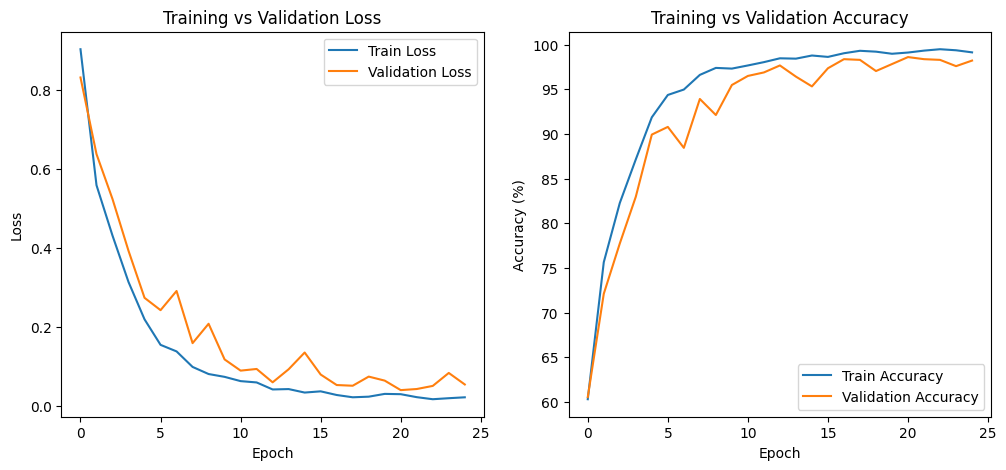

In [6]:
# Plot Training REsults 
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# LOSS PLOT
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# ACCURACY PLOT
plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

# Observations :

### Training vs Validation Loss:
#### - model has converged nicely. Loss curves are smooth and decreasing, which is a good sign of stable training.

### Training vs Validation Accuracy:
#### - Model generalizes well to unseen data. Accuracy above 99% is excellent for a classification task.

### Metrics on epoch 25 :
#### - The model is very accurate
#### - Low validation loss
#### - No large divergence between train and val → model is robust

In [7]:
import os

model_dir = "Model"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "neurosight_alzheimer_model.pth")

torch.save(model.state_dict(), model_path)

print(f"✅ Model saved successfully in: {model_path}")

✅ Model saved successfully in: Model/neurosight_alzheimer_model.pth
